# Дополнительное задание 6: ограниченная оптимизация

Минимизируем число умерших при пике ниже 30% в каждом из пяти обучающих прогонов.

## Окружение

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

comprehensive_analysis (generic function with 2 methods)

## Целевая функция и ограничение

In [2]:
function constrained_cost(x)
    r = objective_replicates(x)
    r.max_peak < 0.30 ? r.death_fraction : 1.0 + r.max_peak
end
constrained_cost([0.1, 3.0, 0.01])
Random.seed!(202646)
result = bboptimize(
    constrained_cost,
    [0.1, 3.0, 0.01];
    Method = :adaptive_de_rand_1_bin,
    SearchRange = [(0.1, 1.0), (3.0, 14.0), (0.01, 0.1)],
    NumDimensions = 3,
    MaxTime = 120.0,
    TraceMode = :silent,
)
best = best_candidate(result)
training = objective_replicates(best)
@assert training.max_peak < 0.30

## Независимая проверка на двадцати новых seed

In [3]:
rows = NamedTuple[]
for seed in 1001:1020
    model = initialize_sir(;
        β_und = fill(best[1], 3),
        β_det = fill(best[1]/10, 3),
        detection_time = round(Int, best[2]),
        death_rate = best[3],
        seed,
    )
    push!(rows, merge((; seed), metrics(model)))
end
validation = DataFrame(rows)
validation.feasible = validation.peak .< 0.30
CSV.write(datafile("sir_extra_6", "validation.csv"), validation)
jldsave(
    datafile("sir_extra_6", "optimization_result.jld2");
    best,
    training,
    validation_passed = all(validation.feasible),
    validation_seeds = 1001:1020,
)
parameters = DataFrame(
    beta = [best[1]],
    detection_time = [round(Int, best[2])],
    death_rate = [best[3]],
    training_max_peak = [training.max_peak],
    validation_max_peak = [maximum(validation.peak)],
    validation_passed = [all(validation.feasible)],
)
CSV.write(datafile("sir_extra_6", "parameters.csv"), parameters)
display(parameters)

Row,beta,detection_time,death_rate,training_max_peak,validation_max_peak,validation_passed
,Float64,Int64,Float64,Float64,Float64,Bool
1,0.1,3,0.01,0.000666667,0.00133333,true


## Проверочные пики

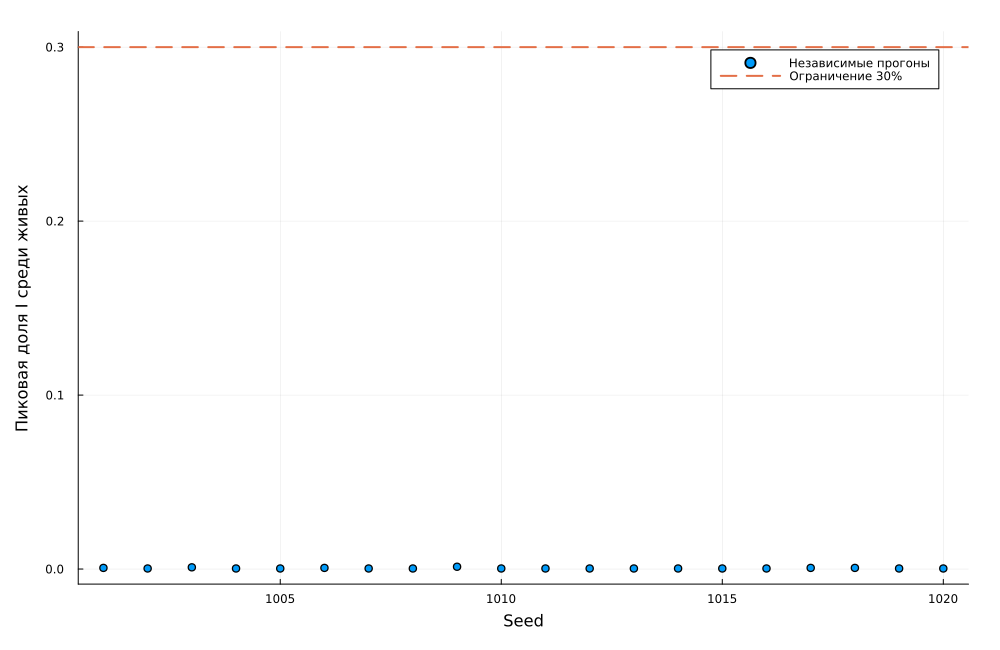

Row,seed,peak,peak_time,final_inf,final_rec,deaths,death_fraction,feasible
,Int64,Float64,Int64,Float64,Float64,Int64,Float64,Bool
1,1001,0.000666667,1,0.0,0.000666667,0,0.0,true
2,1002,0.000333333,0,0.0,0.000333333,0,0.0,true
3,1003,0.001,3,0.0,0.001,0,0.0,true
4,1004,0.000333333,0,0.0,0.000333333,0,0.0,true
5,1005,0.000333333,0,0.0,0.000333333,0,0.0,true
6,1006,0.000666667,1,0.0,0.000666667,0,0.0,true
7,1007,0.000333333,0,0.0,0.000333333,0,0.0,true
8,1008,0.000333333,0,0.0,0.000333333,0,0.0,true
9,1009,0.00133333,12,0.0,0.00133333,0,0.0,true


In [4]:
figure = scatter(
    validation.seed,
    validation.peak;
    label = "Независимые прогоны",
    xlabel = "Seed",
    ylabel = "Пиковая доля I среди живых",
)
hline!(figure, [0.30]; label = "Ограничение 30%", linestyle = :dash)
savefig(figure, imagefile("14-plot.png"))
display(figure)
validation

Проверка на конечном наборе seed не доказывает ограничение для всех
случайных траекторий и не гарантирует глобального оптимума.